### Basic LangGraph

A LangGraph graph has three parts:

**Part:**	What it is

**Node:**	A function that does something

**Edge:**	A connection saying "after this node, go here"

**State:**	Shared data passed between nodes

In [1]:
import os
import logging
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END, add_messages
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage
from langchain_core.tools import tool

from IPython.display import Image, display

In [2]:
load_dotenv()

True

**Two Nodes, One Edge, No State**

Define the Two Nodes

In [3]:
def node_a(state):
    '''A simple node that prints a message.'''
    print('Node A is running')
    return {}

def node_b(State):
    '''Another simple node that prints a message'''
    print('Node B is running')
    return {}


Build the Graph

In [4]:
# Create a graph that uses a dictionary as its state
builder = StateGraph(dict)

# Add the two nodes
builder.add_node('node_a', node_a)
builder.add_node('node_b', node_b)

# Wire them: START → A → B → END
builder.add_edge(START, 'node_a')
builder.add_edge('node_a', 'node_b')
builder.add_edge('node_b', END)

# Compile the graph into a runnable app
app = builder.compile()

print('Graph compiled')

Graph compiled


Run the Graph

In [5]:
result = app.invoke({})

print(f'Final state: {result}')

Node A is running
Node B is running
Final state: {}


Visualize the Graph

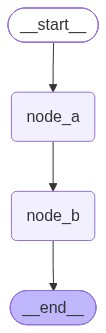

Graph visualized


In [6]:
try:
    display(Image(app.get_graph().draw_mermaid_png()))
    print('Graph visualized')

except Exception as e:
    print(f'PNG rendering failed: {e}')
    print('\nFalling back to ASCII diagram:')
    print(app.get_graph().draw_ascii)

**Adding State**

State is a shared dictionary that:

* Starts with initial values (passed to invoke)

* Gets updated by each node

* Ends up as the final result

Define a State Schema

In [7]:
class CounterState(TypedDict):
    '''The shape of shared state.'''
    
    counter: int
    messages: list
    
print('State schema defined')
print(f'   Fields: {CounterState.__annotations__}')

State schema defined
   Fields: {'counter': <class 'int'>, 'messages': <class 'list'>}


Define Nodes That Modify State


In [8]:
def increment(state: CounterState) -> dict:
    '''Increases the counter by 1'''
    
    new_count = state['counter'] + 1
    print(f'Increment: {state["counter"]} -> {new_count}')
    
    return {'counter': new_count}

def add_message(state: CounterState) -> dict:
    '''Appends a message to the list.'''
    
    new_messages = state['messages'] + [f'Message after count {state["counter"]}']
    print(f'Add message: {new_messages[-1]}')
    
    return {'messages': new_messages}

print('Nodes defined')

Nodes defined


Router Function
* This is the conditional edge logic — the decision point.

In [9]:
def check_counter(state: CounterState) -> str:
    '''Decide whether to loop or move on.'''
    
    if state['counter'] < 3:
        print(f'counter={state["counter"]} < 3 -> loop again')
        return 'loop'
    
    else:
        print(f'counter={state["counter"]} >= 3 -> move to add_message')
        return 'done'
    
print('Router ready')

Router ready


Build a Graph With This State

In [10]:
# New graph using CounterState
builder = StateGraph(CounterState)

# Add the nodes
builder.add_node('increment', increment)
builder.add_node('add_message', add_message)

# START always goes to increment
builder.add_edge(START, 'increment')

# After increment, use the router to decide the next node
builder.add_conditional_edges(
    'increment',      # source code
    check_counter,    # router function
    {                       # mapping: router label → node name
        'loop': 'increment',
        'done': 'add_message',
    }
)

# add_message ends the graph
builder.add_edge('add_message', END)

# Compile
counter_app = builder.compile()

print('Counter graph compiled')

Counter graph compiled


Test run

In [11]:
result = counter_app.invoke({'counter': 0, 'messages': []})

print()
print('Final state:')
print(f'counter: {result["counter"]}')
print(f'messages: {result["messages"]}')

Increment: 0 -> 1
counter=1 < 3 -> loop again
Increment: 1 -> 2
counter=2 < 3 -> loop again
Increment: 2 -> 3
counter=3 >= 3 -> move to add_message
Add message: Message after count 3

Final state:
counter: 3
messages: ['Message after count 3']


Counter Starts at 5

In [12]:
result = counter_app.invoke({'counter': 5, 'messages': []})

print()
print('Final state:')
print(f'   counter:  {result["counter"]}')
print(f'   messages: {result["messages"]}')

Increment: 5 -> 6
counter=6 >= 3 -> move to add_message
Add message: Message after count 6

Final state:
   counter:  6
   messages: ['Message after count 6']


Visualize the Loop

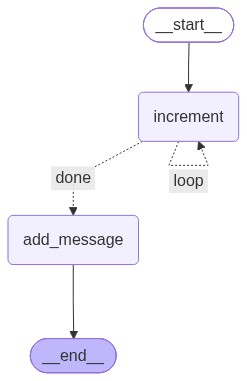

In [13]:
try:
    display(Image(counter_app.get_graph().draw_mermaid_png()))

except Exception:
    print(counter_app.get_graph().draw_ascii())

Adding the LLM Into a Graph Node

In [14]:
# Create the LLM 
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)


State Schema

In [15]:
class QAState(TypedDict):
    question: str
    answer: str
    
print('QAState defined')
print(f'   Fields: {QAState.__annotations__}')

QAState defined
   Fields: {'question': <class 'str'>, 'answer': <class 'str'>}


The LLM Node

In [16]:
def answer_node(state: QAState) -> dict:
    '''
    Send the question to the LLM and store the answer.
    '''
    
    # Read the question from state.
    question = state['question']
    print(f'🤖 Asking LLM: "{question}"')
    
    # Call the LLM
    response = llm.invoke([
        HumanMessage(content=question)
    ])
    
    print(f'📥 LLM replied: "{response.content}"')
    
    return {
        'answer': response.content
    }
    
print('LLM node ready')

LLM node ready


Build the Graph

In [17]:
builder = StateGraph(QAState)

builder.add_node('generate', answer_node)
builder.add_edge(START, 'generate')
builder.add_edge('generate', END)

qa_app = builder.compile()

print('QA graph compiled')

QA graph compiled


The Full Agent Loop in LangGraph
This is the step that ties everything together. 

Define the Tools

In [18]:
@tool
def search_crop_disease(query: str) -> str:
    '''
    Search the crop disease knowledge base for disease information and treatment.
    '''
    
    knowledge = {
        'cassava mosaic': 'Cassava Mosaic Disease: viral, causes yellowing and mottling. Control: disease-free cuttings, resistant varieties, remove infected plants.',
        'maize smut':     'Maize Smut: fungal, causes grey or black galls. Control: resistant hybrids, rotate crops, remove galls.',
        'rice blast':     'Rice Blast: fungal, causes diamond-shaped lesions. Control: resistant varieties, balanced nitrogen, fungicides.',
    }
    
    q = query.lower()
    
    for key, value in knowledge.items():
        if key in q:
            return value
    
    return f'No knowledge found for: {query}'
    
    
@tool
def get_weather(city: str) -> str:
    '''
    Retuen the current weather for a city.
    '''
    
    fake = {
        'lagos': 'Sunny, 32°C, humidity 78%',
        'abuja': 'Cloudy, 28°C, humidity 65%',
        'kano':  'Hot and dry, 36°C, humidity 30%',
    }
    
    return fake.get(city.lower(), f'No weather data for {city}')
    
tools = [search_crop_disease, get_weather]

tools_by_name = {t.name: t for t in tools}

print(f'{len(tools)} tools ready: {tools_by_name}')
    

2 tools ready: {'search_crop_disease': StructuredTool(name='search_crop_disease', description='Search the crop disease knowledge base for disease information and treatment.', args_schema=<class 'pydantic.v1.main.search_crop_diseaseSchema'>, func=<function search_crop_disease at 0x000002777624C040>), 'get_weather': StructuredTool(name='get_weather', description='Retuen the current weather for a city.', args_schema=<class 'pydantic.v1.main.get_weatherSchema'>, func=<function get_weather at 0x0000027775AE3CE0>)}


Bind Tools to the LLM

In [19]:
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)
llm_with_tools = llm.bind_tools(tools)

print('LLM bound to tools')

LLM bound to tools


Define the State

In [20]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]
    
print('AgentState defined')
print(f'    Fields: {AgentState.__annotations__}')

AgentState defined
    Fields: {'messages': typing.Annotated[list, <function add_messages at 0x0000027773ABF920>]}


The Agent Node
* This node asks the LLM what to do next

In [21]:
# Takes the full state (all messages), returns an update.
def agent_node(state: AgentState) -> dict:
    '''
    Ask the LLM what to do — call a tool or answer directly.
    '''
    
    print('🤖 Agent thinking...')
    
    # Sends the entire conversation to the LLM
    response = llm_with_tools.invoke(state['messages'])
    
    # Returns the LLM's response as a list of one message
    return {
        'messages': [response]
    }
    
print('Agent node ready')

Agent node ready


The Tool Node
* This node runs the tool(s) the LLM asked for

In [22]:
def tool_node(state: AgentState) -> dict:
    '''
    Execute every tool call the LLM requested.
    '''
    
    # Read the LLM's most recent message
    last_message = state['messages'][-1]    # the AIMessage

    tool_calls = last_message.tool_calls    # list of tool calls
    
    tool_messages = []
    for call in tool_calls:
        tool_name = call['name']
        tool_args = call['args']
        tool_id = call['id']
        
        print(f'Calling {tool_name}({tool_args})')
        
        # Look up the tool by name and run the tool
        tool_obj = tools_by_name[tool_name]
        result = tool_obj.invoke(tool_args)
        
        # Wrap the result so the LLM can read it
        tool_messages.append(
            ToolMessage(content=str(result), tool_call_id=tool_id)
        )
        
    # Return all tool results
    return {
        'messages': tool_messages
    }
    
print('Tool node ready')

Tool node ready


The Router Function

In [23]:
def should_use_tools(state: AgentState) -> str:
    '''Check if the LLM asked for a tool call.'''
    
    last_message = state['messages'][-1]
    
    # Check if message have a tool_calls attribute and is  list non-empty
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        print('Router: tool calls detected -> go to tools')
        return 'tools'
    
    else:
        print('Router: no tool calls -> done')
        return 'end'
    
print('Router ready')

Router ready


Wire the Graph

In [24]:
# Connect all the nodes and edges
builder = StateGraph(AgentState)

# Add the two nodes
builder.add_node('agent', agent_node)
builder.add_node('tools', tool_node)

# START always goes to agent first
builder.add_edge(START, 'agent')

# After agent, use the router to decide where to go
builder.add_conditional_edges(
    'agent',               # source node
    should_use_tools,      # router function
    {
        'tools': 'tools',  # label -> node name
        'end': END,     # label -> END
    }
)

# After tools run, always loop back to agent
builder.add_edge('tools', 'agent')

# Compile
agent_app = builder.compile()

print('Full agent graph compiled')

Full agent graph compiled


Run the agent

In [25]:
result = agent_app.invoke({
    'messages': [
        HumanMessage(content='How do I treat maize smut?')
    ]
})

print()
print('-' * 60)
print('FINAL ANSWER:')
print(result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'maize smut treatment'})
🤖 Agent thinking...
Router: no tool calls -> done

------------------------------------------------------------
FINAL ANSWER:
To treat maize smut, you can follow these recommendations:

1. **Use Resistant Hybrids**: Plant maize varieties that are resistant to smut.
2. **Crop Rotation**: Rotate crops to disrupt the life cycle of the fungus.
3. **Remove Galls**: Regularly inspect your maize plants and remove any galls (the grey or black growths caused by the fungus) to prevent further spread.

Implementing these strategies can help manage and control maize smut effectively.


Simple fact lookup (single tool)

In [28]:
result = agent_app.invoke({
    'messages': [HumanMessage(content='How do I treat cassava mosaic disease?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'cassava mosaic disease treatment'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: To treat cassava mosaic disease, you can follow these control measures:

1. **Use Disease-Free Cuttings**: Always plant cuttings from healthy, disease-free plants to prevent the spread of the virus.

2. **Plant Resistant Varieties**: Choose cassava varieties that are resistant to mosaic disease.

3. **Remove Infected Plants**: If you notice any infected plants, remove and destroy them promptly to prevent the disease from spreading to healthy plants.

Implementing these strategies can help manage and control cassava mosaic disease effectively.


Weather lookup (single tool, different domain)

In [29]:
result = agent_app.invoke({
    'messages': [HumanMessage(content='What is the weather in Kano?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling get_weather({'city': 'Kano'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: The weather in Kano is hot and dry, with a temperature of 36°C and humidity at 30%.


Compound question (two tools)

In [30]:
result = agent_app.invoke({
    'messages': [HumanMessage(content='What is the weather in Lagos, and how do I treat rice blast?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling get_weather({'city': 'Lagos'})
Calling search_crop_disease({'query': 'rice blast'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: The current weather in Lagos is sunny with a temperature of 32°C and humidity at 78%.

Regarding rice blast, it is a fungal disease that causes diamond-shaped lesions on the leaves. To treat rice blast, you can take the following measures:

1. **Use resistant varieties**: Plant rice varieties that are resistant to the disease.
2. **Balanced nitrogen application**: Ensure proper nitrogen fertilization to avoid excessive growth that can make plants more susceptible.
3. **Fungicides**: Apply appropriate fungicides as a preventive measure or at the first sign of the disease.

Implementing these strategies can help manage and control rice blast effectively.


No tool needed (general knowledge)

In [31]:
result = agent_app.invoke({
    'messages': [HumanMessage(content='What is 15 multiplied by 3?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: no tool calls -> done

FINAL: 15 multiplied by 3 is 45.


In [32]:
result = agent_app.invoke({
    'messages': [HumanMessage(content='What is the formula for quadratic equation?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: no tool calls -> done

FINAL: The formula for a quadratic equation is given by:

\[ ax^2 + bx + c = 0 \]

where:
- \( a \), \( b \), and \( c \) are constants,
- \( x \) represents the variable.

The solutions for \( x \) can be found using the quadratic formula:

\[ x = \frac{{-b \pm \sqrt{{b^2 - 4ac}}}}{{2a}} \]

Here, \( b^2 - 4ac \) is called the discriminant, which determines the nature of the roots of the quadratic equation.


Out of scope (unknown disease)

In [33]:
result = agent_app.invoke({
    'messages': [HumanMessage(content='How do I treat tomato blight?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'tomato blight'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: It seems that I couldn't find specific information on treating tomato blight. However, I can provide some general tips for managing blight in tomatoes:

1. **Remove Infected Plants**: If you notice any plants showing signs of blight, remove them immediately to prevent the spread to healthy plants.

2. **Improve Air Circulation**: Space your plants adequately to allow for good air circulation, which helps reduce humidity and the likelihood of blight.

3. **Watering Practices**: Water at the base of the plants rather than overhead to keep the leaves dry. Water in the morning to allow any moisture on the leaves to dry during the day.

4. **Mulching**: Use mulch to prevent soil from splashing onto the leaves, which can spread pathogens.

5. **Fungicides**: Consider using fungicides that are effective against blight.

Unknown city

In [34]:
result = agent_app.invoke({
    'messages': [HumanMessage(content='What is the weather in Mars?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: no tool calls -> done

FINAL: I can only provide weather information for cities on Earth. If you have a specific city in mind, please let me know!


In [35]:
result = agent_app.invoke({
    'messages': [HumanMessage(content='What is the weather in Osun and Sokoto?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling get_weather({'city': 'Osun'})
Calling get_weather({'city': 'Sokoto'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: I couldn't find any weather data for Osun and Sokoto. It's possible that the weather information is not available for these locations at the moment.


Visualization

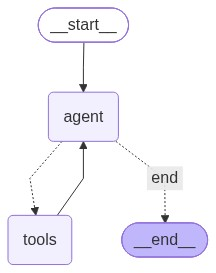

Graph rendered


In [36]:
from IPython.display import Image, display

try:
    display(Image(agent_app.get_graph().draw_mermaid_png()))
    print('Graph rendered')
except Exception as e:
    print(f'PNG failed: {e}')
    print('\nASCII fallback:')
    print(agent_app.get_graph().draw_ascii())

In [38]:
# Turn 1
state = agent_app.invoke({
    'messages': [HumanMessage(content='What is maize smut?')]
})

# Turn 2 — pass history back so the agent remembers
state = agent_app.invoke({
    'messages': state['messages'] + [HumanMessage(content='How do I treat it?')]
})

# Show the final answer
print('\n' + '=' * 60)
print('FINAL ANSWER:')
print(state['messages'][-1].content)
print('=' * 60)

# Show the full message trace
print(f'\nTotal messages: {len(state["messages"])}\n')
for i, msg in enumerate(state['messages']):
    role = msg.__class__.__name__
    content = getattr(msg, 'content', '') or ''
    tool_calls = getattr(msg, 'tool_calls', [])

    if tool_calls:
        calls = ', '.join(f"{tc['name']}({tc['args']})" for tc in tool_calls)
        print(f'[{i}] {role}: 🔧 {calls}')
    else:
        print(f'[{i}] {role}: {str(content)[:90]}')

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'maize smut'})
🤖 Agent thinking...
Router: no tool calls -> done
🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'treatment for maize smut'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL ANSWER:
To treat maize smut, you can follow these control measures:

1. **Use Resistant Hybrids**: Plant maize varieties that are resistant to maize smut to reduce the likelihood of infection.

2. **Crop Rotation**: Rotate crops to disrupt the life cycle of the fungus and minimize the risk of recurrence.

3. **Remove Galls**: Regularly inspect your maize plants and remove any galls that appear. Destroying these galls can help prevent the spread of the disease.

Implementing these strategies can help manage and control maize smut effectively.

Total messages: 8

[0] HumanMessage: What is maize smut?
[1] AIMessage: 🔧 search_crop_disease({'qu

Disease + Weather (logical dependency)

In [39]:
result = agent_app.invoke({
    'messages': [HumanMessage(content=
        'If I am treating rice blast in Kano, do I need to worry about rain today?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling get_weather({'city': 'Kano'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: Today in Kano, the weather is hot and dry with a temperature of 36°C and humidity at 30%. There is no rain expected, so you don't need to worry about rain affecting your treatment for rice blast.


 Negation and Exclusion

In [40]:
result = agent_app.invoke({
    'messages': [HumanMessage(content=
        'Which of these do you have information on: cocoa swollen shoot, maize smut, or wheat rust?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'cocoa swollen shoot'})
Calling search_crop_disease({'query': 'maize smut'})
Calling search_crop_disease({'query': 'wheat rust'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: I have information on maize smut. Here are the details:

- **Maize Smut**: This is a fungal disease that causes grey or black galls on maize plants.
- **Control Measures**: 
  - Use resistant hybrids.
  - Rotate crops.
  - Remove galls to prevent further spread.

Unfortunately, I do not have information on cocoa swollen shoot or wheat rust.


Compound Multi-Part

In [41]:
result = agent_app.invoke({
    'messages': [HumanMessage(content=
        'What is cassava mosaic disease, is it raining in Lagos, and how do I control it?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'cassava mosaic disease'})
Calling get_weather({'city': 'Lagos'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: **Cassava Mosaic Disease** is a viral disease that affects cassava plants, causing symptoms such as yellowing and mottling of the leaves. 

**Control Measures:**
- Use disease-free cuttings for planting.
- Plant resistant varieties of cassava.
- Remove and destroy infected plants to prevent the spread of the disease.

As for the weather in **Lagos**, it is currently sunny with a temperature of 32°C and humidity at 78%. There is no rain at the moment.


Ambiguous Pronoun Across Turns

In [43]:
# Turn 1
state = agent_app.invoke({
    'messages': [HumanMessage(content='Tell me about rice blast.')]
})

# Turn 2 — ask about weather first, distracting from the original topic
state = agent_app.invoke({
    'messages': state['messages'] + [HumanMessage(content='What is the weather in Abuja?')]
})

# Turn 3 — NOW reference the original disease with a pronoun
state = agent_app.invoke({
    'messages': state['messages'] + [HumanMessage(content='How do I control it?')]
})

print('\nFINAL:', state['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'rice blast'})
🤖 Agent thinking...
Router: no tool calls -> done
🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling get_weather({'city': 'Abuja'})
🤖 Agent thinking...
Router: no tool calls -> done
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: To control rice blast, you can take the following measures:

1. **Use Resistant Varieties**: Plant rice varieties that are known to be resistant to rice blast.

2. **Balanced Nitrogen Fertilization**: Ensure that nitrogen levels in the soil are balanced, as excessive nitrogen can increase susceptibility to the disease.

3. **Fungicides**: Apply appropriate fungicides as a preventive measure or when symptoms are observed.

4. **Crop Rotation**: Practice crop rotation to reduce the buildup of the pathogen in the soil.

5. **Field Sanitation**: Remove and destroy infected plant debris to minimize the spread of the disea

Cross-Tool Relationship

In [44]:
result = agent_app.invoke({
    'messages': [HumanMessage(content=
        'Is the weather in Kano good for preventing maize smut?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling get_weather({'city': 'Kano'})
🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'maize smut prevention'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: The current weather in Kano is hot and dry, with a temperature of 36°C and humidity at 30%. This type of weather is generally not conducive to the development of maize smut, as the disease thrives in moist conditions.

To prevent maize smut, consider the following control measures:
- Use resistant hybrids of maize.
- Rotate crops to disrupt the life cycle of the fungus.
- Regularly remove any galls that appear on the plants.

Overall, the current weather conditions in Kano are favorable for preventing maize smut.


A question with a wrong assumption

In [45]:
result = agent_app.invoke({
    'messages': [HumanMessage(content=
        'Since rice blast is a viral disease, how do I treat it?')]
})
print('\nFINAL:', result['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'rice blast treatment'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: Rice blast is actually caused by a fungal pathogen, not a viral disease. Here are some treatment and control measures:

1. **Use Resistant Varieties**: Plant rice varieties that are resistant to rice blast.

2. **Balanced Nitrogen Fertilization**: Ensure that nitrogen levels are balanced, as excessive nitrogen can increase susceptibility.

3. **Fungicides**: Apply appropriate fungicides as a preventive measure or at the first sign of disease.

4. **Cultural Practices**: Implement good agricultural practices, such as crop rotation and proper field drainage, to reduce disease incidence.

5. **Monitoring**: Regularly monitor fields for early signs of the disease to take timely action.

If you need more specific recommendations or details, feel free to ask!


User changes their mind mid-conversation


In [46]:
# Turn 1
state = agent_app.invoke({
    'messages': [HumanMessage(content='How do I treat cassava mosaic disease?')]
})

# Turn 2 — correct yourself
state = agent_app.invoke({
    'messages': state['messages'] + [HumanMessage(content=
        'Actually, I meant rice blast, not cassava mosaic.')]
})

print('\nFINAL:', state['messages'][-1].content)

🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'cassava mosaic disease treatment'})
🤖 Agent thinking...
Router: no tool calls -> done
🤖 Agent thinking...
Router: tool calls detected -> go to tools
Calling search_crop_disease({'query': 'rice blast treatment'})
🤖 Agent thinking...
Router: no tool calls -> done

FINAL: To treat rice blast disease, you can follow these control measures:

1. **Use Resistant Varieties**: Plant rice varieties that are resistant to rice blast to reduce the risk of infection.

2. **Balanced Nitrogen Fertilization**: Ensure that nitrogen is applied in a balanced manner, as excessive nitrogen can increase susceptibility to the disease.

3. **Fungicides**: Apply appropriate fungicides as a preventive measure or at the first sign of disease symptoms to control the spread of the fungus.

Implementing these strategies can help manage and control rice blast disease effectively.
